In [1]:
from pynq_dpu import DpuOverlay
overlay = DpuOverlay("dpu.bit")

/usr/local/share/pynq-venv/lib/python3.8/site-packages/pydantic/_internal/_config.py:322: UserWarning: Valid config keys have changed in V2:
* 'underscore_attrs_are_private' has been removed
  warnings.warn(message, UserWarning)
/usr/local/share/pynq-venv/lib/python3.8/site-packages/pydantic/_internal/_config.py:322: UserWarning: Valid config keys have changed in V2:
* 'underscore_attrs_are_private' has been removed
  warnings.warn(message, UserWarning)
/usr/local/share/pynq-venv/lib/python3.8/site-packages/pynq/pl_server/xrt_device.py:59: UserWarning: xbutil failed to run - unable to determine XRT version
  warnings.warn("xbutil failed to run - unable to determine XRT version")


In [2]:
overlay.load_model("CNN_kv260.xmodel")

In [3]:
from time import time
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
%matplotlib inline
import xir

In [4]:
!pwd

/home/root/jupyter_notebooks/pt_unet_nyudepthv2_ubuntu


In [7]:
image_dir= "images"

In [11]:
listimage=os.listdir(image_dir)
data = {
"image": [x for x in listimage if x.endswith(".png")],
"depth": [x for x in listimage if x.endswith(".npy")]
}

In [12]:
len(data["image"]), len(data["depth"])

(500, 500)

In [24]:
def preprocess_fn(image_path):
    image = cv2.imread(os.path.join(image_dir,image_path))
    image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.reshape(224,224,3)
    image = image * (1/255.0)
    image= (image-0.5)*2 

    return image

In [68]:
def preprocess_npy(depth_path):
    de = np.load(os.path.join(image_dir,depth_path)).astype(np.float32).squeeze()
    de = (de - 0.7)/(10.0 - 0.7)
    de = np.clip(de, 0.0, 1.0)
    de = de.reshape((224,224,1))
    return de

In [69]:
im= preprocess_fn(data["image"][1])
de= preprocess_npy(data["depth"][1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


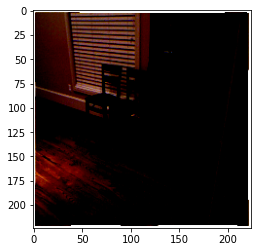

In [70]:
plt.imshow(im)

In [71]:
test_data= np.empty((len(data["image"]),224,224,3))
test_label= np.empty((len(data["depth"]),224,224,1))
#test_data.shape
i=0
for i in range(len(data["image"])):
    
    #image_path= os.path.join(image_dir, data["image"][i])
    img_pre= preprocess_fn(data["image"][i])
    test_data[i,...]= img_pre
    img_pre= preprocess_npy(data["depth"][i])
    test_label[i,...]= img_pre
    i+=1



In [73]:
test_data[0].shape, test_label[0].shape

((224, 224, 3), (224, 224, 1))

In [74]:
test_data.min(), test_data.max(), test_label.min(), test_label.max()

(-1.0, 1.0, 0.0, 0.9999814629554749)

In [75]:
dpu = overlay.runner

inputTensors = dpu.get_input_tensors()
outputTensors = dpu.get_output_tensors()

shapeIn = tuple(inputTensors[0].dims)
shapeOut = tuple(outputTensors[0].dims)
outputSize = int(outputTensors[0].get_data_size() / shapeIn[0])

softmax = np.empty(outputSize)

In [113]:
shapeIn, shapeOut

((1, 224, 224, 3), (1, 224, 224, 1))

In [121]:
output_data = [np.empty(shapeOut, dtype=np.float32, order="C")]
input_data = [np.empty(shapeIn, dtype=np.float32, order="C")]
image = input_data[0]
depth = output_data[0]

In [122]:
input_data[0].shape, output_data[0].shape

((1, 224, 224, 3), (1, 224, 224, 1))

In [123]:
test_data.shape

(500, 224, 224, 3)

In [124]:
test_label.shape

(500, 224, 224, 1)

In [125]:
image[0,...] = test_data[0]
depth[0,...] = test_label[0]
image.shape, depth.shape

((1, 224, 224, 3), (1, 224, 224, 1))

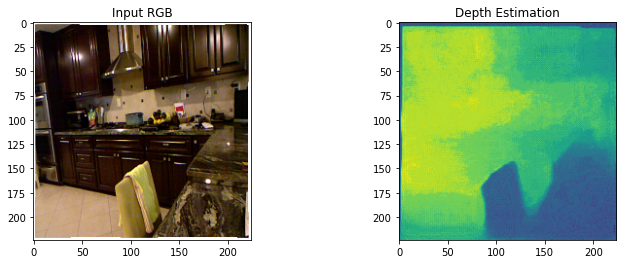

In [128]:
image[0,...] = test_data[0]
depth[0,...] = test_label[0]
job_id = dpu.execute_async(input_data, output_data)
dpu.wait(job_id)
# plt.imshow(output_data[0].squeeze())
temp = [j.reshape(1, outputSize) for j in output_data]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].set_title("Input RGB")
ax[0].imshow((test_data[0] + 1.0)/2.0)

ax[1].set_title("Depth Estimation")
ax[1].imshow((output_data[0].squeeze() + 1.0)/2.0)



In [134]:
test_label.shape[0], test_data.shape[0]

(500, 500)

In [146]:
total = test_data.shape[0]
# test_label=np.array(labels)

print("Estimate depth from {} pictures ...".format(total))
correct=0
start = time()

for i in range(total):
    #print(i)
    image[0,...] = test_data[i]
    job_id = dpu.execute_async(input_data, output_data)
    dpu.wait(job_id)

stop = time()
#correct = np.sum(clases_np[predictions]==test_label)
execution_time = stop-start

print("Execution time: {:.4f}s".format(execution_time))
print("    Throughput: {:.4f}FPS".format(total/execution_time))

Estimate depth from 500 pictures ...
Execution time: 9.3934s
    Throughput: 53.2290FPS


In [147]:
def latency_measurement():
    image[0,...] = test_data[0]
    job_id = dpu.execute_async(input_data, output_data)
    dpu.wait(job_id)
   

In [148]:
one_image_validation_time = %timeit -n 1 -o latency_measurement()

18.8 ms ± 107 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [149]:
del overlay
del dpu